In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seaborn
from collections import Counter
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import load_model

(x_train, y_train), (x_test, y_test) = mnist.load_data()

D:\zmei\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
x_train = x_train / 255
x_test = x_test / 255

C:\Users\user\AppData\Local\Temp\ipykernel_6684\3259019841.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


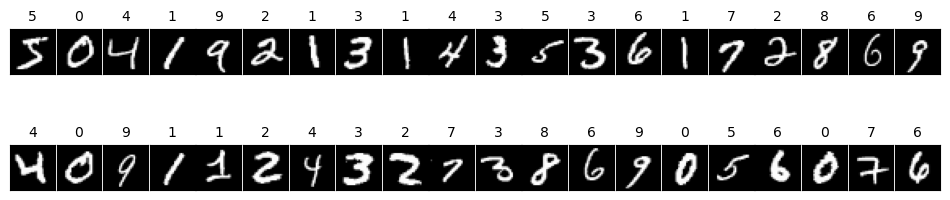

In [3]:
def visualize_images(data):
    fig, axes = plt.subplots(nrows=2, ncols=20, figsize=(12,3),
                             gridspec_kw={'wspace':0.04, 'hspace':0.01}, 
                             squeeze=True)
    
    for i, ax in enumerate(axes.flat):
        ax.imshow(x_train[i], cmap='gray')
        ax.set_xticks([]), ax.set_yticks([])
        ax.set_title(str(y_train[i]), fontsize=10)
        
    plt.tight_layout()
    plt.show()

visualize_images(x_train)

In [4]:
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping

model = keras.Sequential([
    keras.Input(shape = x_train.shape[1:]),
    keras.layers.Flatten(),
    keras.layers.Dense(x_train.shape[1]),
    keras.layers.Dropout(0.3),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(x_train.shape[1], activation ='relu', kernel_regularizer='l1'),
    keras.layers.Dense(10, activation ='softmax')
])

model.compile(  optimizer = keras.optimizers.Adam(learning_rate = 1e-2),
                loss = 'sparse_categorical_crossentropy',
                metrics = ['accuracy']
                )

early_stopping = EarlyStopping(
                    monitor='val_loss',
                    mode='min',
                    patience = 20,
                    min_delta = 0.01,
                    verbose = 0,
                    restore_best_weights = True
                    )

model.fit(
        x = x_train,
        y = y_train,
        batch_size = 64,
        epochs = 2000,
        verbose = 0,
        callbacks = [early_stopping], 
        shuffle = False,
        validation_split = 0.1,
        validation_data = None,
        validation_batch_size = 64
        )

train_loss, keras_train_acc = model.evaluate(x_train, y_train)
test_loss, keras_test_acc = model.evaluate(x_test, y_test)
print('\nдля нейронной сети точность для обучающей \ тестовой выборки:', keras_train_acc, ' \ ', keras_test_acc)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 698us/step - accuracy: 0.9325 - loss: 0.3694
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - accuracy: 0.9254 - loss: 0.3817

для нейронной сети точность для обучающей \ тестовой выборки: 0.9324833154678345  \  0.9254000186920166


In [5]:
num = 15
arr_predict = model.predict(x_test)[:num]
for i in range(1, num):
    print('predict: ', np.argmax(arr_predict[i]), 'true: ', y_test[i], '\tthe same?', np.argmax(arr_predict[i]) == y_test[i])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step
predict:  2 true:  2 	the same? True
predict:  1 true:  1 	the same? True
predict:  0 true:  0 	the same? True
predict:  4 true:  4 	the same? True
predict:  1 true:  1 	the same? True
predict:  4 true:  4 	the same? True
predict:  9 true:  9 	the same? True
predict:  6 true:  5 	the same? False
predict:  9 true:  9 	the same? True
predict:  0 true:  0 	the same? True
predict:  6 true:  6 	the same? True
predict:  9 true:  9 	the same? True
predict:  0 true:  0 	the same? True
predict:  1 true:  1 	the same? True


In [6]:
model.save_weights(
    r"C:\Users\user\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\w.weights.h5", overwrite=True
)

In [7]:
from tensorflow.keras.datasets import fashion_mnist

(x_train_ff, y_train_ff), (x_test_ff, y_test_ff) = fashion_mnist.load_data()

C:\Users\user\AppData\Local\Temp\ipykernel_6684\2858376335.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


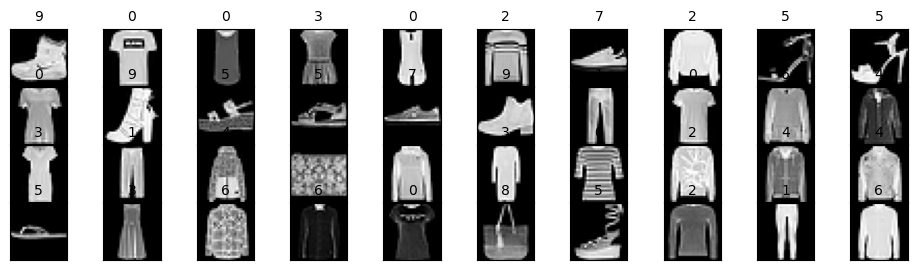

In [8]:
def visualize_images_fash(data):
    fig, axes = plt.subplots(nrows=4, ncols=10, figsize=(12,3),
                             gridspec_kw={'wspace':0.04, 'hspace':0.01}, 
                             squeeze=True)
    
    for i, ax in enumerate(axes.flat):
        ax.imshow(x_train_ff[i], cmap='gray')
        ax.set_xticks([]), ax.set_yticks([])
        ax.set_title(str(y_train_ff[i]), fontsize=10)
        
    plt.tight_layout()
    plt.show()

visualize_images_fash(x_train_ff)

In [9]:
#делаем 8 классов, а не 10
y_train_f = []
y_test_f = []
x_train_f = []
x_test_f = []

for i in range(len(y_train_ff)):
    if y_train_ff[i] in [8, 9]:
        continue
    else:
        y_train_f.append(y_train_ff[i])
        x_train_f.append(x_train_ff[i])

for i in range(len(y_test_ff)):
    if y_test_ff[i] in [8, 9]:
        continue
    else:
        y_test_f.append(y_test_ff[i])
        x_test_f.append(x_test_ff[i])


In [10]:
y_train_f = np.array(y_train_f)
y_test_f = np.array(y_test_f)
x_train_f = np.array(x_train_f)
x_test_f = np.array(x_test_f)

In [11]:
from sklearn.base import BaseEstimator, TransformerMixin

class Scaler(BaseEstimator, TransformerMixin):
    def __init__(self, feature):
        self.feature = feature

    def fit(self, X, y = None):
        #должно быть определение полей, но их тут не будет
        return self

    def transform(self, X, y = None):
        x_transformed = X.copy()
        x_transformed = x_transformed / self.feature
        return x_transformed

In [14]:
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

class NeuralNetworkTrainer():
    def __init__(self, epochs=2000, batch_size=64, verbose=0, lr = 5e-2, pat = 50, num_cl = 10):
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.lr = lr
        self.pat = pat
        self.num_cl = num_cl
        self.model = None

    def fit(self, X, y=None):
        X = np.array(X)
        y = np.array(y)
        model_f = keras.Sequential([
            keras.Input(shape = X.shape[1:]),
            keras.layers.Flatten(),
            keras.layers.Dense(X.shape[1]),
            keras.layers.Dropout(0.3),
            keras.layers.BatchNormalization(),
            keras.layers.Dense(X.shape[1], activation ='relu', kernel_regularizer='l1'),
            keras.layers.Dense(10)
        ])

        model_f.load_weights(
            r"C:\Users\user\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\w.weights.h5", skip_mismatch = True
        )

        for layer in model_f.layers:
            layer.trainable = False

        model_f.add(keras.layers.BatchNormalization())
        model_f.add(keras.layers.Dense(X.shape[1]))
        model_f.add(keras.layers.Dense(self.num_cl, activation ='softmax'))

        model_f.compile( optimizer = keras.optimizers.Adam(learning_rate = self.lr),
                        loss = 'sparse_categorical_crossentropy',
                        metrics = ['accuracy']
                        )

        early_stopping = EarlyStopping(
                            monitor='val_loss',
                            mode='min',
                            patience = self.pat,
                            min_delta = 0.01,
                            verbose = 0,
                            restore_best_weights = True
                            )

        model_f.fit(
                x = X,
                y = y,
                batch_size = self.batch_size,
                epochs = self.epochs,
                verbose = self.verbose,
                callbacks = [early_stopping], 
                shuffle = False,
                validation_split = 0.1,
                validation_data = None,
                validation_batch_size = self.batch_size
                )    

        self.model = model_f
        return self

    def transform(self, X):
        return X

    def predict(self, X):
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X)
        return np.argmax(y_pred, axis=1)

    def score(self, X, y=None):
        # Оцените производительность модели на данных X и y
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X)
        accuracy = accuracy_score(y, np.argmax(y_pred, axis=1))
        return accuracy


In [40]:
pipe = Pipeline([
    ('MinMaxScaler', Scaler(255)),
    ('neural_network_trainer', NeuralNetworkTrainer(num_cl = 8, verbose = 0))
])

pipe.fit(x_train_f, y_train_f)

Pipeline(steps=[('MinMaxScaler', Scaler(feature=255)),
                ('neural_network_trainer',
                 <__main__.NeuralNetworkTrainer object at 0x0000025E6A691590>)])

In [41]:
import warnings
from sklearn.exceptions import NotFittedError
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.pipeline")

print('\nв keras точность для обучающей \ тестовой выборки:', pipe.score(x_train_f, y_train_f), ' \ ', pipe.score(x_test_f, y_test_f))

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 541us/step 
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step

в keras точность для обучающей \ тестовой выборки: 0.6260833333333333  \  0.62175


In [42]:
num = 15
predicts = pipe.predict(x_test_f)[:num]
trues = y_test_f[:num]
for i in range(1, num):
    print('predict: ', predicts[i], 'true: ', trues[i], '\tthe same?', predicts[i] == trues[i])

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step
predict:  1 true:  1 	the same? True
predict:  1 true:  1 	the same? True
predict:  4 true:  6 	the same? False
predict:  1 true:  1 	the same? True
predict:  1 true:  4 	the same? False
predict:  6 true:  6 	the same? True
predict:  5 true:  5 	the same? True
predict:  7 true:  7 	the same? True
predict:  4 true:  4 	the same? True
predict:  5 true:  5 	the same? True
predict:  5 true:  7 	the same? False
predict:  3 true:  3 	the same? True
predict:  4 true:  4 	the same? True
predict:  1 true:  1 	the same? True


In [35]:
import tensorflow as tf
import torch

#конвертер файла весов из keras для pytorch

# Параметры
h5_path = r"C:\Users\user\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\w.weights.h5"
input_dim = 28*28
output_pth = "mnist_base_weights.pth"

# Построение Keras модели
model = keras.Sequential([
    keras.Input(shape = x_train.shape[1:]),
    keras.layers.Flatten(),
    keras.layers.Dense(x_train.shape[1], name='fc1'),
    keras.layers.Dropout(0.3, name='dropout'),
    keras.layers.BatchNormalization(name='bn1'),
    keras.layers.Flatten(name='flatten'),
    keras.layers.Dense(x_train.shape[1], activation='relu', kernel_regularizer='l1', name='fc2'),
    keras.layers.Dense(10, name='fc3')
])

# Загрузка весов
model.load_weights(h5_path)

# Извлечение весов в удобный формат
weights = {}
for layer in model.layers:
    if layer.name.startswith('fc') or layer.name.startswith('bn'):
        w = layer.get_weights()
        weights[layer.name] = w
        print(f"{layer.name}: {[arr.shape for arr in w]}")

# Создание PyTorch BaseModel
class BaseModel(torch.nn.Module):
    def __init__(self, input_dim):
        super(BaseModel, self).__init__()
        self.flatten = torch.nn.Flatten()
        self.fc1 = torch.nn.Linear(input_dim, 28)
        self.dropout = torch.nn.Dropout(0.3)
        self.bn1 = torch.nn.BatchNorm1d(28)
        self.fc2 = torch.nn.Linear(28, 28)
        self.fc3 = torch.nn.Linear(28, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.dropout(x)
        x = self.bn1(x)
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

base_model = BaseModel(input_dim)

state_dict = base_model.state_dict()


fc1_kernel, fc1_bias = weights['fc1']
state_dict['fc1.weight'] = torch.tensor(fc1_kernel.T) 
state_dict['fc1.bias'] = torch.tensor(fc1_bias)

bn1_gamma, bn1_beta, bn1_mean, bn1_var = weights['bn1']
state_dict['bn1.weight'] = torch.tensor(bn1_gamma)
state_dict['bn1.bias'] = torch.tensor(bn1_beta)
state_dict['bn1.running_mean'] = torch.tensor(bn1_mean)
state_dict['bn1.running_var'] = torch.tensor(bn1_var)

fc2_kernel, fc2_bias = weights['fc2'] 
state_dict['fc2.weight'] = torch.tensor(fc2_kernel.T)
state_dict['fc2.bias'] = torch.tensor(fc2_bias)

fc3_kernel, fc3_bias = weights['fc3']
state_dict['fc3.weight'] = torch.tensor(fc3_kernel.T)
state_dict['fc3.bias'] = torch.tensor(fc3_bias)

torch.save(state_dict, output_pth)
print(f"Saved to {output_pth}")

fc1: [(784, 28), (28,)]
bn1: [(28,), (28,), (28,), (28,)]
fc2: [(28, 28), (28,)]
fc3: [(28, 10), (10,)]
Saved to mnist_base_weights.pth


In [36]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, TransformerMixin

class NeuralNetworkTrainerPyTorchTransfer(BaseEstimator, TransformerMixin):

    def __init__(self, epochs=2000, batch_size=64, verbose=0, lr=5e-2,
                 patience=50, num_cl=8, pretrained_weights_path=None,
                 shuffle=False, device=None):
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.lr = lr
        self.patience = patience
        self.num_cl = num_cl
        self.pretrained_weights_path = pretrained_weights_path
        self.shuffle = shuffle
        self.device = device if device is not None \
                      else ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None
        self._best_model_state = None
        self.input_features = None

    def fit(self, X, y):

        self.input_features = X.shape[1]

        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.long)

        val_size = int(0.1 * len(X_tensor))
        train_size = len(X_tensor) - val_size
        train_dataset, val_dataset = torch.utils.data.random_split(TensorDataset(X_tensor, y_tensor), [train_size, val_size])

        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=self.shuffle)
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)

        self.model = self._build_full_model().to(self.device)

        if self.pretrained_weights_path is not None:
            try:
                state_dict = torch.load(self.pretrained_weights_path, map_location=self.device)
                self.model.base.load_state_dict(state_dict, strict=False)
                if self.verbose > 0:
                    print(f"Предобученные веса загружены из {self.pretrained_weights_path}")
            except Exception as e:
                print(f"Не удалось загрузить веса: {e}. Используется случайная инициализация.")

        # Замораживаем все параметры базовой модели
        for param in self.model.base.parameters():
            param.requires_grad = False

        # head будут обучаться
        head_params = list(self.model.head.parameters())

        # Оптимизатор (только для головы)
        optimizer = optim.Adam(head_params, lr=self.lr)
        criterion = nn.CrossEntropyLoss()

        best_val_loss = np.inf
        patience_counter = 0
        min_delta = 0.01

        for epoch in range(1, self.epochs + 1):
            self.model.train()
            train_loss = 0.0
            train_correct = 0
            train_total = 0

            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)

                loss.backward()
                optimizer.step()

                train_loss += loss.item() * batch_X.size(0)
                _, predicted = torch.max(outputs, 1)
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y).sum().item()

            avg_train_loss = train_loss / train_total
            train_acc = train_correct / train_total

            self.model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                    outputs = self.model(batch_X)
                    loss = criterion(outputs, batch_y)

                    val_loss += loss.item() * batch_X.size(0)
                    _, predicted = torch.max(outputs, 1)
                    val_total += batch_y.size(0)
                    val_correct += (predicted == batch_y).sum().item()

            avg_val_loss = val_loss / val_total
            val_acc = val_correct / val_total

            if self.verbose > 0 and epoch%20 == 0:
                print(f"Epoch {epoch}/{self.epochs} - "
                      f"train_loss: {avg_train_loss:.4f}, train_acc: {train_acc:.4f}, "
                      f"val_loss: {avg_val_loss:.4f}, val_acc: {val_acc:.4f}")

            if avg_val_loss < best_val_loss - min_delta:
                best_val_loss = avg_val_loss
                patience_counter = 0
                self._best_model_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    if self.verbose > 0:
                        print(f"Early stopping на эпохе {epoch}")
                    break

        if self._best_model_state is not None:
            self.model.load_state_dict(self._best_model_state)
            self.model.to(self.device)

        return self

    def transform(self, X):
        return X

    def predict(self, X):

        if self.model is None:
            raise ValueError("Модель не обучена")

        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
            outputs = self.model(X_tensor)
            _, predicted = torch.max(outputs, 1)
            return predicted.cpu().numpy()

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def _build_full_model(self):

        # class BaseModel(nn.Module):
        #     def __init__(self, input_features):
        #         super(BaseModel, self).__init__()
        #         self.flatten = nn.Flatten()
        #         self.fc1 = nn.Linear(input_features, input_features)
        #         self.dropout = nn.Dropout(0.3)
        #         self.bn1 = nn.BatchNorm1d(input_features)
        #         self.fc2 = nn.Linear(input_features, input_features)
        #         self.fc3 = nn.Linear(input_features, 10)

        #     def forward(self, x):
        #         x = self.flatten(x)
        #         x = self.fc1(x)
        #         x = self.dropout(x)
        #         x = self.bn1(x)
        #         x = torch.relu(self.fc2(x))
        #         x = self.fc3(x)
        #         return x

        class HeadModel(nn.Module):
            def __init__(self, input_features, num_cl):
                super(HeadModel, self).__init__()
                self.bn = nn.BatchNorm1d(10)          
                self.fc4 = nn.Linear(10, input_features)
                self.fc5 = nn.Linear(input_features, num_cl)

            def forward(self, x):
                x = self.bn(x)
                x = self.fc4(x)                   
                x = self.fc5(x)                      
                return x

        class FullModel(nn.Module):
            def __init__(self, base, head):
                super(FullModel, self).__init__()
                self.base = base
                self.head = head

            def forward(self, x):
                x = self.base(x)
                x = self.head(x)
                return x

        base = BaseModel(self.input_features**2)
        head = HeadModel(self.input_features, self.num_cl)
        model = FullModel(base, head)
        return model

In [37]:
pipeline_pytorch = Pipeline([
    ('MinMaxScaler', Scaler(255)),
    ('neural_network_trainer', NeuralNetworkTrainerPyTorchTransfer(num_cl = 8, verbose = 1, pretrained_weights_path='mnist_base_weights.pth'))
])

pipeline_pytorch.fit(x_train_f, y_train_f)

Предобученные веса загружены из mnist_base_weights.pth
Epoch 20/2000 - train_loss: 1.2522, train_acc: 0.5089, val_loss: 1.1004, val_acc: 0.5913
Epoch 40/2000 - train_loss: 1.2508, train_acc: 0.5073, val_loss: 1.1145, val_acc: 0.5835
Epoch 60/2000 - train_loss: 1.2487, train_acc: 0.5107, val_loss: 1.0969, val_acc: 0.6098
Epoch 80/2000 - train_loss: 1.2518, train_acc: 0.5067, val_loss: 1.1378, val_acc: 0.5533
Epoch 100/2000 - train_loss: 1.2408, train_acc: 0.5108, val_loss: 1.0941, val_acc: 0.5813
Epoch 120/2000 - train_loss: 1.2485, train_acc: 0.5095, val_loss: 1.0906, val_acc: 0.5921
Early stopping на эпохе 120


Pipeline(steps=[('MinMaxScaler', Scaler(feature=255)),
                ('neural_network_trainer',
                 NeuralNetworkTrainerPyTorchTransfer(device='cpu',
                                                     pretrained_weights_path='mnist_base_weights.pth',
                                                     verbose=1))])

In [38]:
print('\nв pytorch точность для обучающей \ тестовой выборки:', pipeline_pytorch.score(x_train_f, y_train_f), ' \ ', pipeline_pytorch.score(x_test_f, y_test_f))
num = 15
predicts = pipeline_pytorch.predict(x_test_f)[:num]
trues = y_test_f[:num]
for i in range(1, num):
    print('predict: ', predicts[i], 'true: ', trues[i], '\tthe same?', predicts[i] == trues[i])


в pytorch точность для обучающей \ тестовой выборки: 0.6168333333333333  \  0.609
predict:  3 true:  1 	the same? False
predict:  1 true:  1 	the same? True
predict:  4 true:  6 	the same? False
predict:  4 true:  1 	the same? False
predict:  1 true:  4 	the same? False
predict:  4 true:  6 	the same? False
predict:  5 true:  5 	the same? True
predict:  7 true:  7 	the same? True
predict:  4 true:  4 	the same? True
predict:  5 true:  5 	the same? True
predict:  7 true:  7 	the same? True
predict:  3 true:  3 	the same? True
predict:  4 true:  4 	the same? True
predict:  1 true:  1 	the same? True


In [43]:
print('\nв keras точность для обучающей \ тестовой выборки:', pipe.score(x_train_f, y_train_f), ' \ ', pipe.score(x_test_f, y_test_f))
print('\nв pytorch точность для обучающей \ тестовой выборки:', pipeline_pytorch.score(x_train_f, y_train_f), ' \ ', pipeline_pytorch.score(x_test_f, y_test_f))

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 526us/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step

в keras точность для обучающей \ тестовой выборки: 0.6260833333333333  \  0.62175

в pytorch точность для обучающей \ тестовой выборки: 0.6168333333333333  \  0.609
